<a href="https://colab.research.google.com/github/Saikonfate/TDE1-IA/blob/Michel%2FAn%C3%A1lise-de-valores-ausentes-e-duplicados/integrante_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 3. Qualidade dos Dados

### 3.1 Valores ausentes

In [ ]:
ausentes_abs = df.isna().sum()
ausentes_pct = (df.isna().mean() * 100).round(2)
qualidade_ausentes = pd.DataFrame({"ausentes (qtd)": ausentes_abs, "ausentes (%)": ausentes_pct})
qualidade_ausentes


,ausentes (qtd),ausentes (%)
product_name,0,0.0
overall_rating,0,0.0
no_ratings,0,0.0
no_reviews,0,0.0
rating,0,0.0
title,0,0.0
review,0,0.0
review_chars,0,0.0
review_words,0,0.0
title_chars,0,0.0


In [ ]:
total_ausentes = int(df.isna().sum().sum())
print(f"Total de células ausentes no dataset inteiro: {total_ausentes}")


Total de células ausentes no dataset inteiro: 0


**Interpretação:** conforme calculado acima, o dataset **não possui valores ausentes** em
nenhuma coluna original. Isso é uma boa notícia para a qualidade dos dados, mas não dispensa a
investigação de outros problemas (strings vazias, valores "mascarados" como ausentes, duplicatas
etc.), que são tratados nas próximas subseções.

### 3.2 Duplicatas

In [ ]:
dup_completa = df.duplicated().sum()
dup_completa_pct = round(dup_completa / len(df) * 100, 2)
print(f"Linhas totalmente duplicadas (todas as colunas iguais): {dup_completa} ({dup_completa_pct}% do dataset)")

# Duplicatas considerando apenas produto + texto da avaliação (ignora title)
dup_prod_review = df.duplicated(subset=["product_name", "review"]).sum()
print(f"Duplicatas por (product_name, review): {dup_prod_review} ({round(dup_prod_review/len(df)*100,2)}%)")

# Quantidade de linhas envolvidas em algum grupo de duplicação (contando a primeira ocorrência também)
linhas_em_grupos_duplicados = df.duplicated(keep=False).sum()
print(f"Linhas que pertencem a algum grupo de duplicatas (incluindo a 1ª ocorrência): "
      f"{linhas_em_grupos_duplicados} ({round(linhas_em_grupos_duplicados/len(df)*100,2)}%)")


Linhas totalmente duplicadas (todas as colunas iguais): 7122 (29.54% do dataset)
Duplicatas por (product_name, review): 7789 (32.3%)
Linhas que pertencem a algum grupo de duplicatas (incluindo a 1ª ocorrência): 12931 (53.63%)


In [ ]:
print("Exemplos de linhas totalmente duplicadas:")
exemplo_dup = df[df.duplicated(keep=False)].sort_values(["product_name", "review"]).head(8)
exemplo_dup[["product_name", "rating", "title", "review"]]


Exemplos de linhas totalmente duplicadas:


,product_name,rating,title,review
6282,ASUS Expertbook Intel Core i7 12th Gen 1255U - (16 GB/512 GB S...,5,Awesome,Awesome product..value for money
7537,ASUS Expertbook Intel Core i7 12th Gen 1255U - (16 GB/512 GB S...,5,Awesome,Awesome product..value for money
6284,ASUS Expertbook Intel Core i7 12th Gen 1255U - (16 GB/512 GB S...,3,Just okay,Battery lasts only 1 to 2 hour
7539,ASUS Expertbook Intel Core i7 12th Gen 1255U - (16 GB/512 GB S...,3,Just okay,Battery lasts only 1 to 2 hour
6289,ASUS Expertbook Intel Core i7 12th Gen 1255U - (16 GB/512 GB S...,1,Waste of money!,Don't waste your money on buying this laptop.\nPerformance - You can't perfo...
7544,ASUS Expertbook Intel Core i7 12th Gen 1255U - (16 GB/512 GB S...,1,Waste of money!,Don't waste your money on buying this laptop.\nPerformance - You can't perfo...
6278,ASUS Expertbook Intel Core i7 12th Gen 1255U - (16 GB/512 GB S...,4,Wonderful,Everything is good except worst delivery experience by ecart as always
7533,ASUS Expertbook Intel Core i7 12th Gen 1255U - (16 GB/512 GB S...,4,Wonderful,Everything is good except worst delivery experience by ecart as always


In [ ]:
print("Textos de avaliação mais repetidos para o MESMO produto (top 10):")
top_reviews_repetidas = (
    df.groupby(["product_name", "review"]).size().sort_values(ascending=False).head(10)
)
top_reviews_repetidas


Textos de avaliação mais repetidos para o MESMO produto (top 10):


product_name                                                       review      
HP AMD Athlon Dual Core 3050U - (8 GB/512 GB SSD/Windows 11 Ho...  Good            24
HP 15s Intel Core i3 11th Gen 1115G4 - (8 GB/512 GB SSD/Window...  Good            20
CHUWI Intel Celeron Dual Core 11th Gen N4020 - (8 GB/256 GB SS...  Good            20
DELL Intel Core i3 12th Gen 1215U - (8 GB/512 GB SSD/Windows 1...  Good            18
HP Victus Intel Core i5 12th Gen - (16 GB/512 GB SSD/Windows 1...  Good            16
HP (15s-fq5007TU) Intel Core i3 12th Gen 1215U - (8 GB/512 GB ...  Good            12
CHUWI Intel Celeron Dual Core 11th Gen N4020 - (8 GB/256 GB SS...  Nice            12
ZEBRONICS Pro Series Z Intel Core i5 12th Gen 1235U - (8 GB/51...  Good            12
DELL Inspiron 15 with Backlit Keyboard, Intel Core i5 12th Gen...  Good product    12
ASUS Vivobook 15 Intel Core i3 11th Gen 1115G4 - (8 GB/256 GB ...  Good            12
dtype: int64

**Interpretação:** o percentual de linhas totalmente duplicadas calculado acima é expressivo.
Ao investigar exemplos concretos, observa-se que a duplicação **não parece ser um erro de coleta**,
mas sim um efeito natural do domínio: muitos clientes escrevem avaliações extremamente curtas e
genéricas para o mesmo produto (por exemplo, o texto `"Good"` aparece dezenas de vezes associado ao
mesmo `product_name`, escrito por clientes diferentes). Como `no_ratings`, `no_reviews` e
`overall_rating` são atributos do **produto** (repetidos em toda avaliação daquele produto), e como
títulos como "Wonderful" ou "Good" são extremamente comuns, é estatisticamente esperado que diferentes
clientes produzam linhas idênticas por coincidência de texto curto - não porque a mesma avaliação foi
inserida duas vezes no sistema.

**Decisão adotada nesta etapa:** as duplicatas **não serão removidas**. Removê-las eliminaria
avaliações genuínas de clientes distintos (perda de informação real), e para o problema de
classificação de texto essas repetições podem inclusive ser úteis (reforçam o vocabulário típico de
cada classe de rating). A decisão sobre remover ou não duplicatas antes do treinamento do modelo deve
ser reavaliada na etapa de modelagem, considerando o risco de vazamento de dados (a mesma frase
aparecendo em treino e teste) - isso é registrado como ponto de atenção na conclusão.

### 3.3 Valores inconsistentes

In [ ]:
colunas_para_checar = ["product_name", "title", "review"]
for col in colunas_para_checar:
    com_espaco_extra = (df[col].astype(str) != df[col].astype(str).str.strip()).sum()
    print(f"'{col}': {com_espaco_extra} valores com espaços extras no início/fim")

print()

for col in colunas_para_checar:
    vazios = (df[col].astype(str).str.strip() == "").sum()
    print(f"'{col}': {vazios} strings vazias")


'product_name': 0 valores com espaços extras no início/fim
'title': 0 valores com espaços extras no início/fim
'review': 0 valores com espaços extras no início/fim

'product_name': 0 strings vazias
'title': 0 strings vazias
'review': 0 strings vazias


In [ ]:
# Checagem de categorias 'duplicadas' por diferença de capitalização/espaçamento em product_name
produtos_normalizados = df["product_name"].astype(str).str.strip().str.lower()
n_categorias_originais = df["product_name"].nunique()
n_categorias_normalizadas = produtos_normalizados.nunique()
print(f"Categorias distintas em 'product_name' (originais): {n_categorias_originais}")
print(f"Categorias distintas em 'product_name' (após strip + lower): {n_categorias_normalizadas}")
print(f"Diferença (possíveis duplicatas de grafia): {n_categorias_originais - n_categorias_normalizadas}")


Categorias distintas em 'product_name' (originais): 365
Categorias distintas em 'product_name' (após strip + lower): 365
Diferença (possíveis duplicatas de grafia): 0


In [ ]:
# Checagem análoga para 'title'
titles_normalizados = df["title"].astype(str).str.strip().str.lower()
n_titles_originais = df["title"].nunique()
n_titles_normalizados = titles_normalizados.nunique()
print(f"Categorias distintas em 'title' (originais): {n_titles_originais}")
print(f"Categorias distintas em 'title' (após strip + lower): {n_titles_normalizados}")
print(f"Diferença (possíveis duplicatas de grafia): {n_titles_originais - n_titles_normalizados}")


Categorias distintas em 'title' (originais): 213
Categorias distintas em 'title' (após strip + lower): 210
Diferença (possíveis duplicatas de grafia): 3


**Interpretação:** não foram encontrados espaços extras nem strings vazias nas colunas
textuais/categóricas verificadas. A comparação entre o número de categorias originais e o número de
categorias após normalização (letras minúsculas e remoção de espaços nas bordas) mostra se existem
"categorias duplicadas" por diferença apenas de grafia/capitalização - se a diferença calculada acima
for zero, isso significa que **não há esse tipo de inconsistência** relevante em `product_name` nem em
`title` neste dataset. Caso a diferença seja maior que zero, isso indica categorias que deveriam ser
unificadas (ex.: `"Wonderful"` e `"wonderful "` sendo tratadas como categorias diferentes).

### 3.4 Valores inválidos

Definimos os intervalos válidos com base no **significado real** das colunas, sem inventar limites:

- `rating`: nota individual do cliente, deve estar entre **1 e 5** (escala usada pela Flipkart);
- `overall_rating`: nota média do produto, também deve estar entre **1 e 5** (é uma média de notas
  de 1 a 5), na prática, tende a ficar em uma faixa mais estreita, pois é uma média;
- `no_ratings` e `no_reviews`: contagens, portanto **não podem ser negativas**;
- logicamente, `no_reviews` (avaliações com texto) **não pode ser maior que** `no_ratings` (notas
  totais), pois toda avaliação com texto também contribui com uma nota.

In [ ]:
rating_invalido = ((df["rating"] < 1) | (df["rating"] > 5)).sum()
overall_invalido = ((df["overall_rating"] < 1) | (df["overall_rating"] > 5)).sum()
no_ratings_negativo = (no_ratings_num < 0).sum()
no_reviews_negativo = (no_reviews_num < 0).sum()
reviews_maior_que_ratings = (no_reviews_num > no_ratings_num).sum()

print(f"Valores de 'rating' fora do intervalo [1, 5]: {rating_invalido}")
print(f"Valores de 'overall_rating' fora do intervalo [1, 5]: {overall_invalido}")
print(f"Valores negativos em 'no_ratings': {no_ratings_negativo}")
print(f"Valores negativos em 'no_reviews': {no_reviews_negativo}")
print(f"Linhas em que 'no_reviews' > 'no_ratings' (logicamente impossível): {reviews_maior_que_ratings}")


Valores de 'rating' fora do intervalo [1, 5]: 0
Valores de 'overall_rating' fora do intervalo [1, 5]: 0
Valores negativos em 'no_ratings': 0
Valores negativos em 'no_reviews': 0
Linhas em que 'no_reviews' > 'no_ratings' (logicamente impossível): 0


**Interpretação:** com base nos resultados calculados acima, **não foram encontrados valores
inválidos** nas variáveis numéricas segundo as regras de negócio definidas (nenhuma nota fora da
escala, nenhuma contagem negativa e nenhuma inconsistência lógica entre `no_reviews` e `no_ratings`).
Isso é um indício de que o processo de coleta dos dados foi relativamente cuidadoso quanto a esses
aspectos.

### 3.5 Tipos inadequados

In [ ]:
print("Tipos ANTES da correção:")
print(df[["no_ratings", "no_reviews"]].dtypes)
print()
print("Exemplos de valores brutos:", df["no_ratings"].unique()[:5].tolist())


Tipos ANTES da correção:
no_ratings    str
no_reviews    str
dtype: object

Exemplos de valores brutos: ['15,210', '5,248', '3,899', '660', '1,323']


In [ ]:
# Justificativa: 'no_ratings' e 'no_reviews' representam contagens (variáveis numéricas por
# natureza), mas foram lidas como texto (object) porque contêm vírgula como separador de milhar
# (ex.: "15,210"). Corrigimos o tipo para inteiro, removendo o separador.

df["no_ratings"] = df["no_ratings"].astype(str).str.replace(",", "", regex=False).astype(int)
df["no_reviews"] = df["no_reviews"].astype(str).str.replace(",", "", regex=False).astype(int)

print("Tipos DEPOIS da correção:")
print(df[["no_ratings", "no_reviews"]].dtypes)
print()
df[["no_ratings", "no_reviews"]].head(5)


Tipos DEPOIS da correção:
no_ratings    int64
no_reviews    int64
dtype: object



,no_ratings,no_reviews
0,15210,900
1,15210,900
2,15210,900
3,15210,900
4,15210,900


**Interpretação:** as colunas `no_ratings` e `no_reviews` estavam com o tipo inadequado
(`object`/texto) para colunas que representam contagens. Após a remoção do separador de milhar e a
conversão para `int`, essas colunas passam a poder ser usadas corretamente em cálculos estatísticos,
comparações numéricas e correlações nas próximas seções. A partir deste ponto do notebook, `df` já
contém as colunas corrigidas (as variáveis auxiliares `no_ratings_num`/`no_reviews_num` criadas
anteriormente deixam de ser necessárias).

### 3.6 Outliers

Vamos investigar outliers pelo método do **Intervalo Interquartil (IQR)** nas variáveis numéricas em
que esse conceito faz sentido: `no_ratings`, `no_reviews`, `review_chars` e `review_words`. Não
aplicamos IQR em `rating`, pois é uma variável discreta e ordinal com apenas 5 valores possíveis. O
conceito de "outlier estatístico" não se aplica bem a uma escala Likert fechada.

In [ ]:
def resumo_outliers_iqr(serie, nome):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    outliers = ((serie < limite_inferior) | (serie > limite_superior))
    return {
        "variável": nome,
        "Q1": q1, "Q3": q3, "IQR": iqr,
        "limite_inferior": round(limite_inferior, 2),
        "limite_superior": round(limite_superior, 2),
        "qtd_outliers": int(outliers.sum()),
        "pct_outliers": round(outliers.sum() / len(serie) * 100, 2),
    }

resultado_outliers = pd.DataFrame([
    resumo_outliers_iqr(df["no_ratings"], "no_ratings"),
    resumo_outliers_iqr(df["no_reviews"], "no_reviews"),
    resumo_outliers_iqr(df["review_chars"], "review_chars"),
    resumo_outliers_iqr(df["review_words"], "review_words"),
]).set_index("variável")

resultado_outliers


,Q1,Q3,IQR,limite_inferior,limite_superior,qtd_outliers,pct_outliers
variável,,,,,,,
no_ratings,660.0,3475.0,2815.0,-3562.5,7697.5,1555,6.45
no_reviews,62.0,310.0,248.0,-310.0,682.0,1715,7.11
review_chars,17.0,123.0,106.0,-142.0,282.0,2168,8.99
review_words,3.0,22.0,19.0,-25.5,50.5,2183,9.05


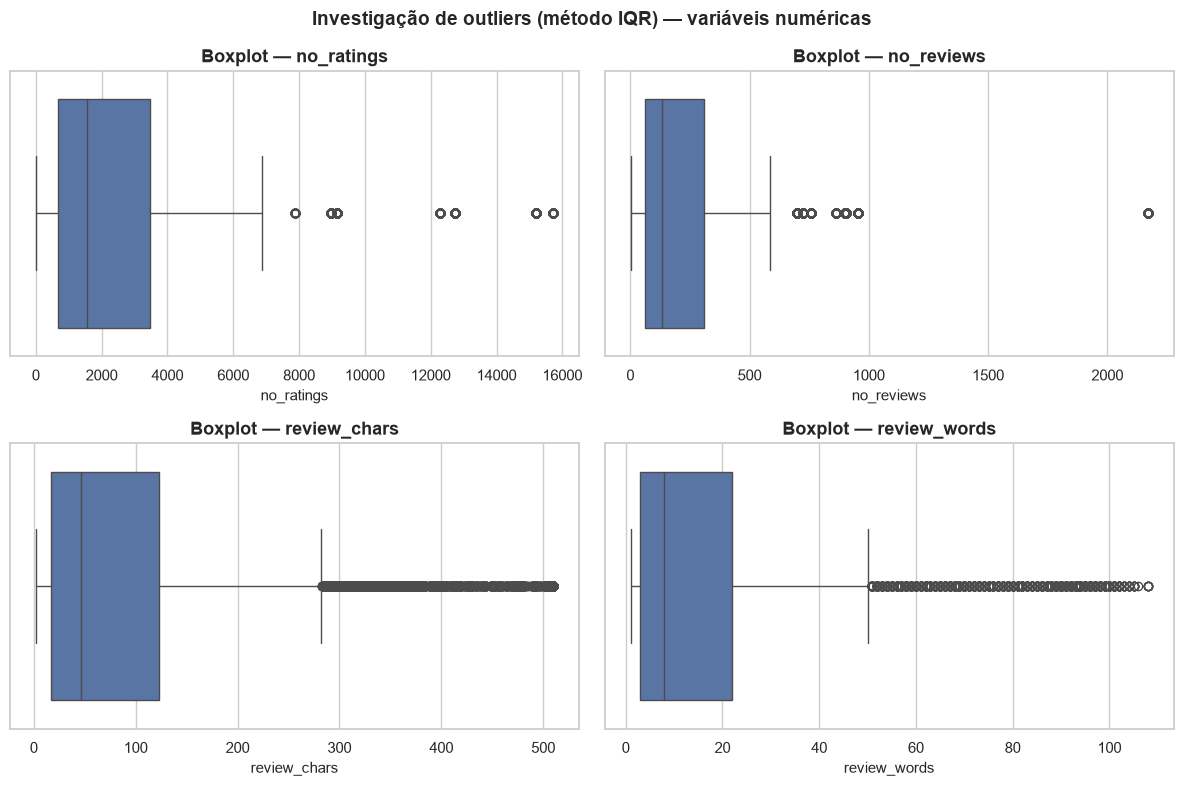

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), ["no_ratings", "no_reviews", "review_chars", "review_words"]):
    sns.boxplot(x=df[col], ax=ax, color="#4C72B0")
    ax.set_title(f"Boxplot — {col}")
    ax.set_xlabel(col)
fig.suptitle("Investigação de outliers (método IQR) — variáveis numéricas", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


**Interpretação:** o método IQR aponta uma quantidade não desprezível de possíveis outliers
nessas quatro variáveis (percentuais calculados na tabela acima). No entanto, ao interpretar esses
valores à luz do **significado real dos dados**, eles não parecem erros de coleta, e sim
**características legítimas do domínio**:

- em `no_ratings`/`no_reviews`, os valores "extremos" correspondem a **produtos muito populares**
  (best-sellers), que naturalmente acumulam muito mais avaliações que a maioria - é esperado que a
  popularidade de produtos em um marketplace siga uma distribuição de cauda longa;
- em `review_chars`/`review_words`, os valores extremos correspondem a **clientes que escreveram
  avaliações mais detalhadas** (relatos longos de experiência de uso), o que também é um
  comportamento real e útil para o projeto de NLP (reviews mais longas tendem a carregar mais
  informação textual).

**Decisão adotada:** nenhum outlier será removido nesta etapa. Eles representam variação legítima do
fenômeno estudado, não erros de digitação ou falhas de coleta. Essa decisão poderá ser revisitada na
etapa de modelagem caso se verifique que casos extremos prejudicam o treinamento.